In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Estimate π with Monte Carlo

The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

1. Generate **N = 100,000** random (x, y) points where x and y are each drawn from Uniform(−1, 1).
2. Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
3. Estimate π as `4 × (points inside) / N`.
4. Print your estimate alongside the true value of π.
5. Create a scatter plot of the first **5,000** points, coloring inside points differently from outside points. Draw the unit circle on top for reference.

**Convergence plot:** Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

**Guiding question:** At roughly what sample size does your estimate stabilize within ±0.01 of true π?


In [3]:
N=100000
x=np.random.uniform(-1,1,N)
y=np.random.uniform(-1,1,N)
inside=(x**2+y**2<=1)
estimate_pi=4*np.sum(inside)/N
print(f"Estimated: {estimate_pi}")
print(f"Actual pi: {np.pi}")

Estimated: 3.14412
Actual pi: 3.141592653589793


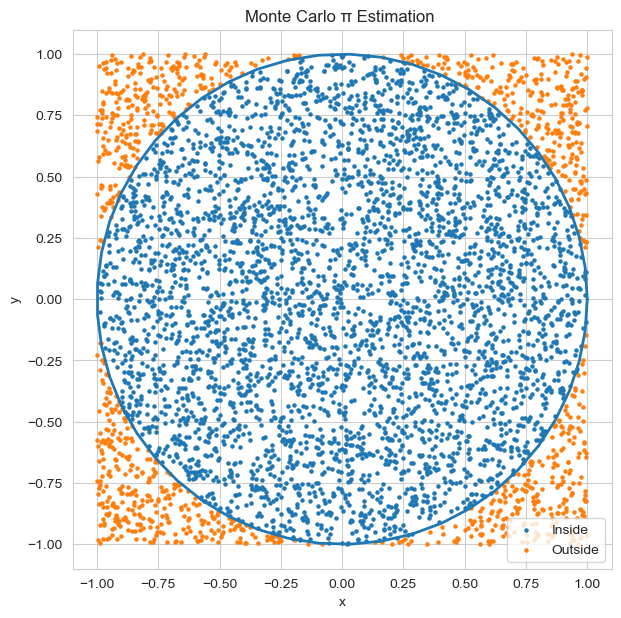

In [4]:
n_plot=5000
plt.figure(figsize=(7,7))
plt.scatter(x[:n_plot][inside[:n_plot]],y[:n_plot][inside[:n_plot]],s=5,label="Inside")
plt.scatter(x[:n_plot][~inside[:n_plot]],y[:n_plot][~inside[:n_plot]],s=5,label="Outside")

theta = np.linspace(0, 2*np.pi)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2)
plt.gca().set_aspect('equal')
plt.title("Monte Carlo π Estimation ")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

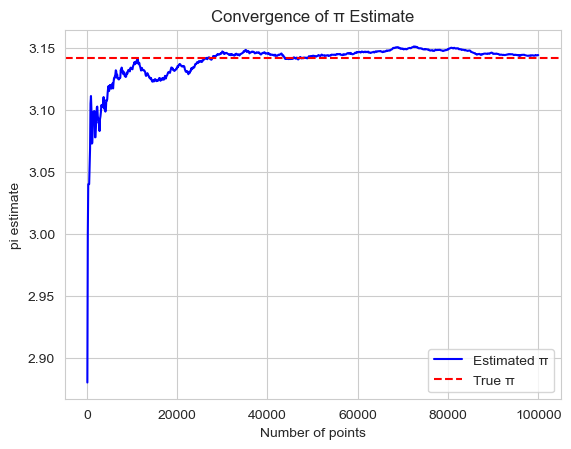

In [5]:
steps=np.arange(100,N+1,100)
running_estimates=[]
for n in steps:
    estimate = 4 * np.mean(inside[:n])
    running_estimates.append(estimate)
plt.show()
plt.figure()
plt.plot(steps, running_estimates,color="blue", label="Estimated π") 
plt.axhline(np.pi, linestyle='--',color="red", label="True π")
plt.title("Convergence of π Estimate")
plt.xlabel("Number of points")
plt.ylabel("pi estimate")
plt.legend() 


From the convergence plot, the estimate starts to remain within ±0.01 of the true value of π at approximately 10,000 samples. After this point, the fluctuations become small and the estimate stabilizes around π.


### Task 2: Coin Flips and Empirical Probability

Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

1. Simulate **10,000** fair coin flips (use `np.random.choice([0, 1])` or `np.random.binomial(1, 0.5, size=10000)`).
2. Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).
3. Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.
4. Repeat the experiment **5 times** (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

**Guiding question:** How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?


In [6]:
n_flips=10000
flips=np.random.binomial(1,0.5,size=n_flips)
running_prop=np.cumsum(n_flips)/(np.arange(1,n_flips+1))

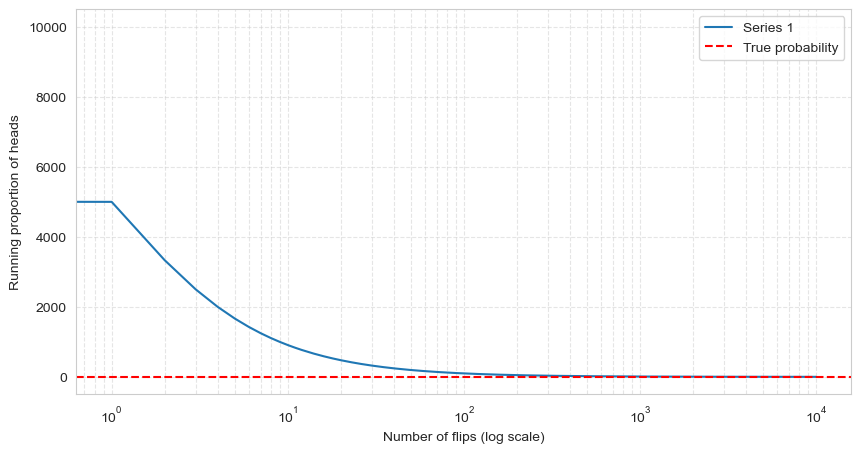

In [7]:
plt.figure(figsize=(10,5))
plt.plot(running_prop,label="Series 1")
plt.axhline(0.5,color="red",linestyle="--",label="True probability")
plt.xscale("log")
plt.xlabel('Number of flips (log scale)')
plt.ylabel('Running proportion of heads')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

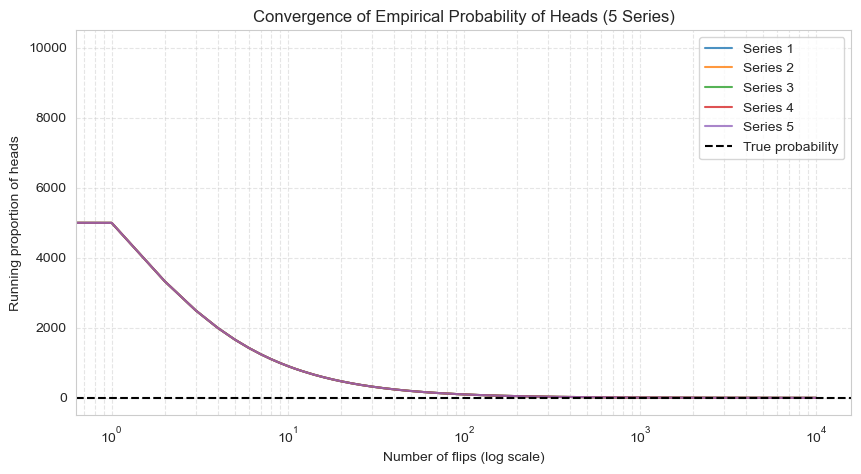

In [8]:
all_props=[]
for i in range(5):
    flips = np.random.binomial(1, 0.5, size=n_flips)
    running_prop = np.cumsum(n_flips) / (np.arange(1, n_flips + 1))
    all_props.append(running_prop)
    
plt.figure(figsize=(10, 5))
for i, running_prop in enumerate(all_props):
    plt.plot(running_prop, label=f'Series {i+1}', alpha=0.8)

plt.axhline(0.5, color='black', linestyle='--', label='True probability')
plt.xscale('log')
plt.xlabel('Number of flips (log scale)')
plt.ylabel('Running proportion of heads')
plt.title('Convergence of Empirical Probability of Heads (5 Series)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Although the simulation runs for 10,000 flips, the running proportion stabilizes much earlier.

Typically, the empirical probability of heads enters and stays within the range 0.49–0.51 after approximately **200 to 500 flips**.

The exact number varies between simulations due to randomness, but convergence generally occurs well before 1,000 flips.

### Task 3: Simulating Binomial Experiments

A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

1. Simulate **10,000 batches** of 50 widgets each, where each widget has a 3% chance of being defective.
2. For each batch, record the number of defective widgets found.
3. Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical Binomial(n=50, p=0.03) PMF as points connected by a line.
4. From your simulation, estimate:
   - P(0 defects in a batch)
   - P(3 or more defects in a batch)
   - The expected number of defects per batch
5. Compare each simulation estimate to the theoretical binomial value (use `scipy.stats.binom` or manual calculation).

**Guiding question:** How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?


In [9]:
batches=10000
n=50
p=0.03
defects=np.random.binomial(n,p,size=batches)

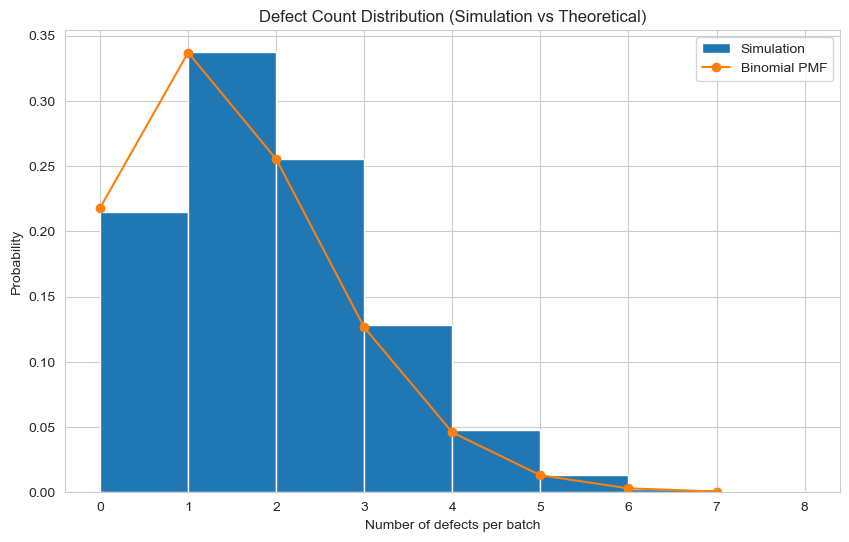

In [10]:
plt.figure(figsize=(10, 6))
counts,bins,_=plt.hist(defects,bins=range(0,max(defects)+2),density=True,label="Simulation")
x=np.arange(0,max(defects)+1)
pmf = binom.pmf(x, n, p)
plt.plot(x, pmf, marker='o', linestyle='-', label='Binomial PMF')
plt.xlabel('Number of defects per batch')
plt.ylabel('Probability')
plt.title('Defect Count Distribution (Simulation vs Theoretical)')
plt.legend()
plt.show()

In [11]:
p_0_sim = np.mean(defects == 0)
p_3plus_sim = np.mean(defects >= 3)
expected_sim = np.mean(defects)

print(p_0_sim,p_3plus_sim,expected_sim)

0.2146 0.1926 1.5115


In [12]:
p_0_theory = binom.pmf(0, n, p)
p_3plus_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p

print(p_0_theory,p_3plus_theory,expected_theory)


0.21806537534740766 0.18920192463027863 1.5


In [13]:
print("P(0 defects):")
print("Simulation:", p_0_sim)
print("Theoretical:", p_0_theory)

print("\nP(3 or more defects):")
print("Simulation:", p_3plus_sim)
print("Theoretical:", p_3plus_theory)

print("\nExpected number of defects:")
print("Simulation:", expected_sim)
print("Theoretical:", expected_theory)

P(0 defects):
Simulation: 0.2146
Theoretical: 0.21806537534740766

P(3 or more defects):
Simulation: 0.1926
Theoretical: 0.18920192463027863

Expected number of defects:
Simulation: 1.5115
Theoretical: 1.5


The empirical estimates are very close to the theoretical values. The differences are small and occur due to randomness in the simulation.

With 10,000 batches, the estimates are highly accurate and stable. If we used only 1,000 batches, the results would still be reasonable, but there would be more variability and less precision.

Therefore, 1,000 batches can give a rough estimate, but 10,000 batches provide more reliable and consistent results.